# Regresión Lineal Múltiple
## Predicción del Puntaje de Riesgo de Diabetes

Este notebook implementa un modelo de **regresión lineal múltiple** para predecir el `diabetes_risk_score` a partir de características demográficas, clínicas y de estilo de vida.

**Dataset:** [Diabetes Health Indicators Dataset - Kaggle](https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data)

---

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


## 2. Carga y Selección de Datos

Se carga el archivo CSV y se seleccionan las columnas relevantes.

| Columna | Nombre | Descripción |
|---------|--------|-------------|
| 0  | `age`                              | Edad del paciente |
| 8  | `physical_activity_minutes_per_week` | Minutos de actividad física por semana |
| 9  | `diet_score`                       | Puntuación de la calidad de la dieta |
| 12 | `family_history_diabetes`          | Antecedentes familiares (0=No, 1=Sí) |
| 15 | `bmi`                              | Índice de masa corporal |
| 16 | `waist_to_hip_ratio`               | Relación cintura-cadera |
| 17 | `systolic_bp`                      | Presión arterial sistólica |
| 21 | `hdl_cholesterol`                  | Colesterol HDL |
| 23 | `triglycerides`                    | Triglicéridos |
| 24 | `glucose_fasting`                  | Glucosa en ayunas |
| 25 | `glucose_postprandial`             | Glucosa postprandial |
| 26 | `insulin_level`                    | Nivel de insulina |
| 27 | `hba1c`                            | Hemoglobina glucosilada (HbA1c) |

**Variable objetivo (col. 28):** `diabetes_risk_score`

In [2]:
data = np.genfromtxt('../Database/1_diabetes_dataset.csv', delimiter=',', skip_header=1)

X = data[:, [0, 8, 9, 12, 15, 16, 17, 21, 23, 24, 25, 26, 27]]
y = data[:, 28]

null_counts_X = np.isnan(X).sum(axis=0)
print("Valores nulos por columna en X (características):")
for i, col_name in enumerate(['age', 'phys', 'diet', 'fam_h', 'bmi', 'whr', 'sys_bp', 'hdl', 'trig', 'gluc_f', 'gluc_p', 'insulin', 'hba1c']):
    print(f"  {col_name}: {null_counts_X[i]}")

# Verificar valores nulos en y
null_y = np.isnan(y).sum()
print(f"Valores nulos en la variable objetivo (risk_score): {null_y}")

rows_with_nulls = np.isnan(X).any(axis=1) | np.isnan(y)
print(f"Filas con al menos un valor nulo: {rows_with_nulls.sum()}")

print('\n{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>10s}'.format(
    'age', 'phys', 'diet', 'fam_h', 'bmi', 'whr', 'sys_bp', 'hdl', 'trig', 'gluc_f', 'gluc_p', 'insulin', 'hba1c', 'risk_score'))
print('-' * 114)
for i in range(10):
    print('{:8.0f}{:8.0f}{:8.1f}{:8.0f}{:8.1f}{:8.2f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.2f}{:8.2f}{:10.1f}'.format(
        X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4], X[i, 5], X[i, 6],
        X[i, 7], X[i, 8], X[i, 9], X[i, 10], X[i, 11], X[i, 12], y[i]))

Valores nulos por columna en X (características):
  age: 0
  phys: 0
  diet: 0
  fam_h: 0
  bmi: 0
  whr: 0
  sys_bp: 0
  hdl: 0
  trig: 0
  gluc_f: 0
  gluc_p: 0
  insulin: 0
  hba1c: 0
Valores nulos en la variable objetivo (risk_score): 0
Filas con al menos un valor nulo: 0

     age    phys    diet   fam_h     bmi     whr  sys_bp     hdl    trig  gluc_f  gluc_p insulin   hba1crisk_score
------------------------------------------------------------------------------------------------------------------
      58     215     5.7       0    30.5    0.89     134      41     145     136     236    6.36    8.18      29.6
      48     143     6.7       0    23.1    0.80     129      55      30      93     150    2.00    5.63      23.0
      60      57     6.4       1    22.2    0.81     115      66      36     118     195    5.07    7.51      44.7
      74      49     3.4       0    26.8    0.88     120      50     140     139     253    5.28    9.03      38.2
      46     109     7.2       0

## 3. Normalización de Características

Se aplica **estandarización Z-score** para escalar las características y evitar que variables con grandes magnitudes dominen el modelo.

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar de cada característica.

In [3]:
def  featureNormalize(X): # Conjunto de columnas o matriz

    X_norm = X.copy() # Travajamos sobre una copy de x para no daniar la original
    mu = np.zeros(X.shape[1]) # Shape[0]numero de filas, shape[1]columnas , mu = media x 
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) # axis 1 fias ,axis 0 columnas 
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [4]:
X_norm, mu, sigma = featureNormalize(X)

## 4. División en Entrenamiento y Prueba

Se divide el dataset en **80% entrenamiento** y **20% prueba**.

In [5]:
x_train, x_test, y_train, y_test =train_test_split(X_norm, y,test_size=0.2, shuffle=False)
X_norm=x_train
y=y_train

## 5. Visualización: Características vs. Variable Objetivo

Se grafican las 13 características (normalizadas) contra el `diabetes_risk_score` para explorar visualmente las relaciones lineales.

In [6]:
# Nombres de las características (basado en tus comentarios)
feature_names = [
    'age', 'physical_activity', 'diet_score', 'family_history', 'bmi', 'waist_to_hip', 'systolic_bp', 'hdl', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]
def plotData(x_feature, y, xlabel, ylabel):
    fig = plt.figure(figsize=(10, 6))
    plt.plot(x_feature, y, 'ro', mec='k', alpha=0.5, markersize=1)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    return fig

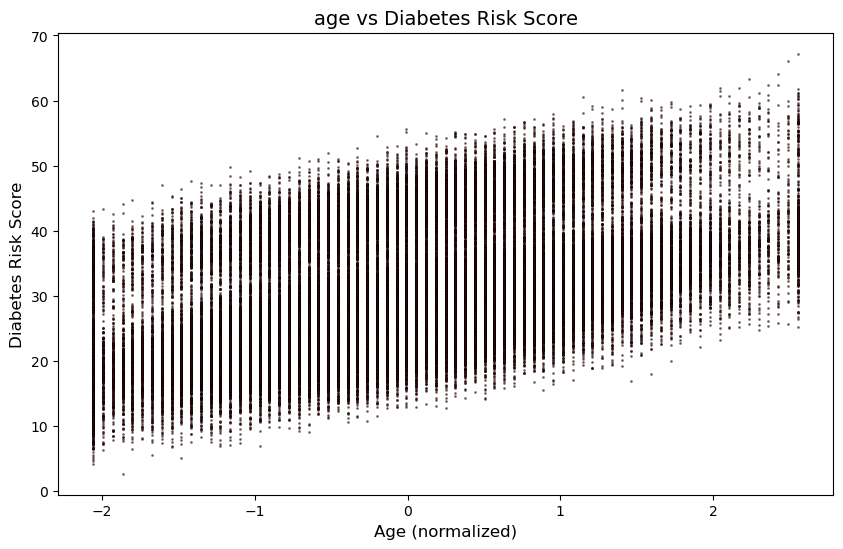

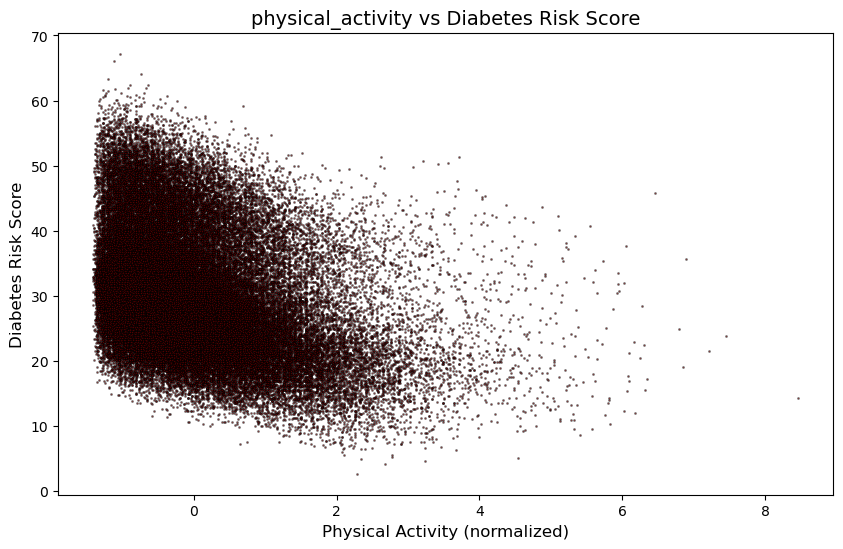

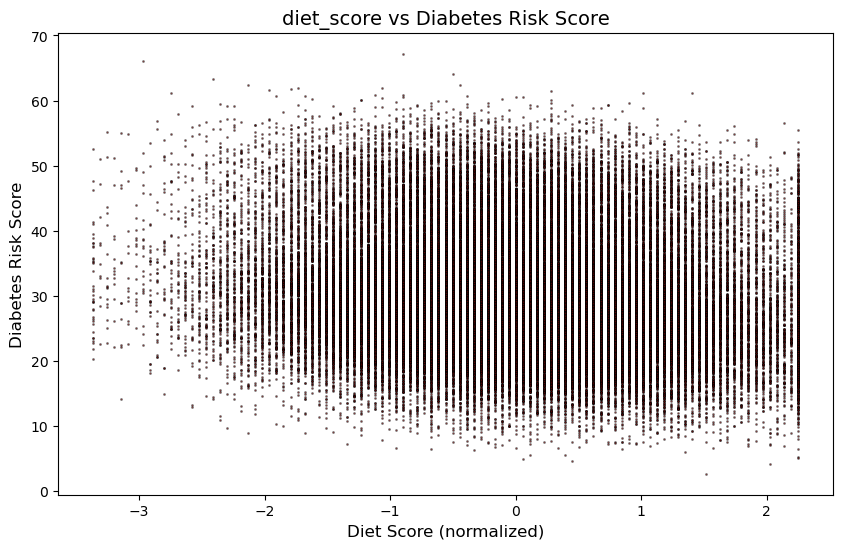

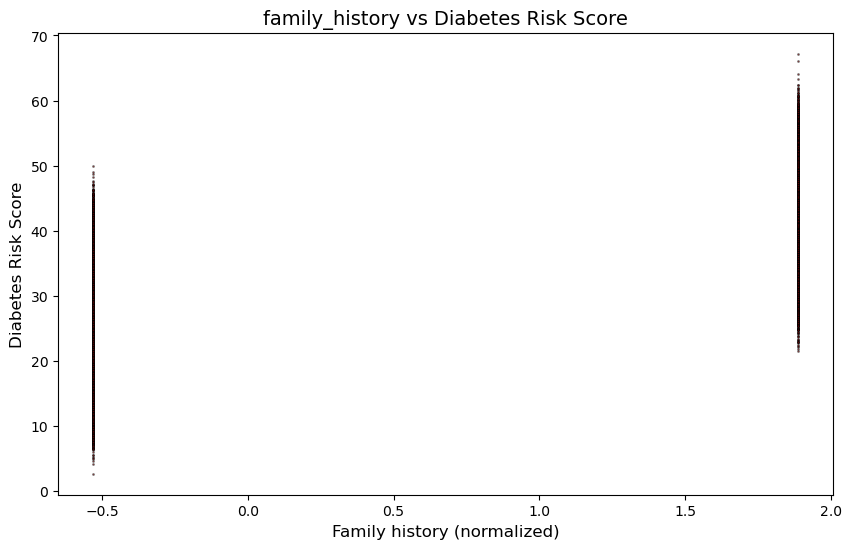

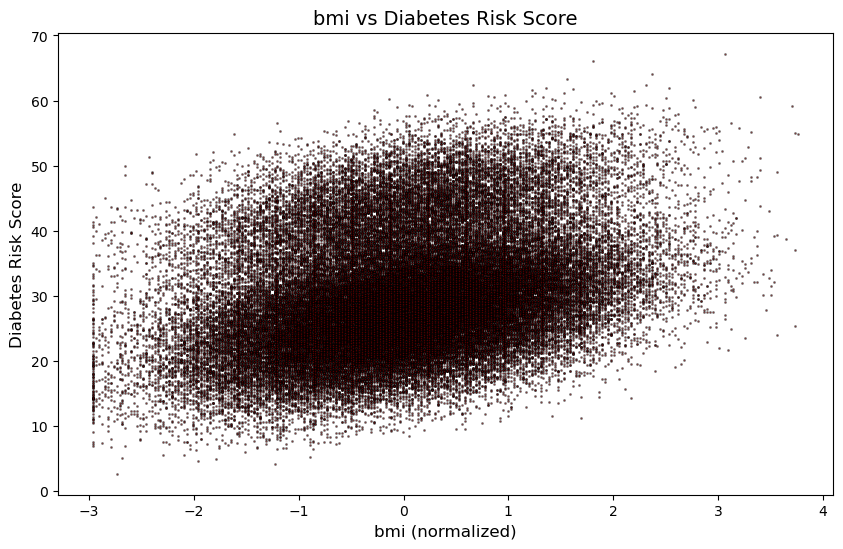

In [7]:
# Definir etiquetas para las primeras características
xlabel1 = 'Age (normalized)'
xlabel2 = 'Physical Activity (normalized)'
xlabel3 = 'Diet Score (normalized)'
xlabel4 = 'Family history (normalized)'
xlabel5 = 'bmi (normalized)'
ylabel = 'Diabetes Risk Score'

plotData(X_norm[:, 0], y, xlabel1, ylabel)
plt.title(f'{feature_names[0]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 1], y, xlabel2, ylabel)
plt.title(f'{feature_names[1]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 2], y, xlabel3, ylabel)
plt.title(f'{feature_names[2]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 3], y, xlabel4, ylabel)
plt.title(f'{feature_names[3]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 4], y, xlabel5, ylabel)
plt.title(f'{feature_names[4]} vs {ylabel}', fontsize=14)
plt.show()


## 6. Fundamentos del Modelo

### Modelo de Regresión Lineal Múltiple

$$y = h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n + \epsilon$$

- $y$: variable dependiente (`diabetes_risk_score`)
- $x_i$: variables independientes (características)
- $\theta_i$: coeficientes del modelo (a estimar)
- $\epsilon$: error aleatorio

### Función de Costo (MSE)

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

## 7. Entrenamiento del Modelo

### 7.1 Preparación: Agregar término de sesgo ($\theta_0$)

Se agrega una columna de unos al inicio de $X$ para representar el término independiente $\theta_0$.

In [8]:
# Agregar columna de unos para el término de sesgo (beta_0)
m = y.size
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

### 7.2 Función de Costo y Descenso por Gradiente

In [9]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [10]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [11]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 4000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

theta calculado por el descenso por el gradiente: [29.66623527  3.80235116 -2.81976719 -0.85286322  6.2563552   1.20604061
  0.27163229  0.41824557 -0.95416747  0.57330714  0.58798699 -0.15889676
  0.04265166 -0.0437409 ]


### 7.3 Curva de Aprendizaje

Text(0.5, 1.0, 'Convergencia del Descenso por Gradiente')

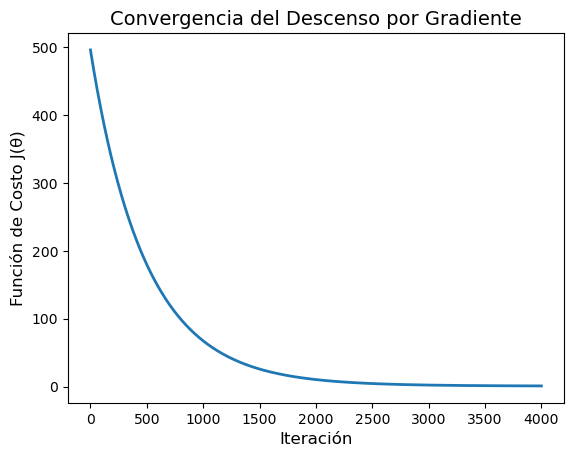

In [12]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Función de Costo J(θ)', fontsize=12)
plt.title('Convergencia del Descenso por Gradiente', fontsize=14)

## 8. Evaluación del Modelo

Se evalúa el modelo sobre el conjunto de prueba usando:
- **MSE** (Error Cuadrático Medio)

In [13]:
# Procesar y predecir con datos de prueba
m_test = y_test.size
x_test_pre = np.concatenate([np.ones((m_test, 1)), x_test], axis=1)
Y_pre = np.dot(x_test_pre, theta)
resultados = pd.DataFrame({
    'Valor_Real': y_test,
    'Prediccion': Y_pre
})
print("\nPrimeras filas del DataFrame 'resultados':")
print(resultados.head(10))


Primeras filas del DataFrame 'resultados':
   Valor_Real  Prediccion
0        18.8   20.219569
1        26.4   26.345365
2        25.9   25.655189
3        17.5   17.493268
4        33.7   34.237211
5        19.8   18.177726
6        31.9   31.631349
7        17.0   19.080335
8        54.6   52.506678
9        21.4   22.761080


## 9. Predicción con Nuevos Datos

Para predecir sobre un nuevo paciente se deben aplicar los mismos valores de `mu` y `sigma` calculados durante el entrenamiento.

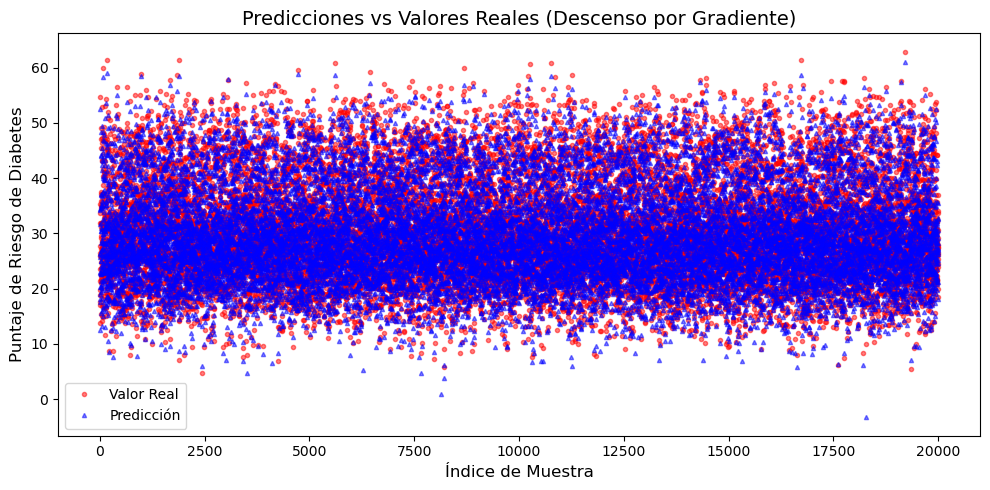

In [14]:
# Graficar Predicciones vs Valores Reales
plt.figure(figsize=(10, 5))
plt.plot(resultados['Valor_Real'].values, 'ro', label='Valor Real', alpha=0.5, markersize=3)
plt.plot(resultados['Prediccion'].values, 'b^', label='Predicción', alpha=0.5, markersize=3)
plt.xlabel('Índice de Muestra', fontsize=12)
plt.ylabel('Puntaje de Riesgo de Diabetes', fontsize=12)
plt.title('Predicciones vs Valores Reales (Descenso por Gradiente)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Validación del Modelo de Regresión Lineal Múltiple

Después de entrenar el modelo lineal con descenso por gradiente, se calcula el costo tanto para el conjunto de entrenamiento como para el conjunto de prueba. Esto permite observar si el modelo está aprendiendo correctamente y si puede generalizar a datos que no fueron usados durante el entrenamiento.

La función de costo utilizada es:

$$J(\theta)=\frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})^2$$


Costo J entrenamiento (Lineal GD): 0.8531
Costo J prueba (Lineal GD): 0.8599
MSE prueba (Lineal GD): 1.7198


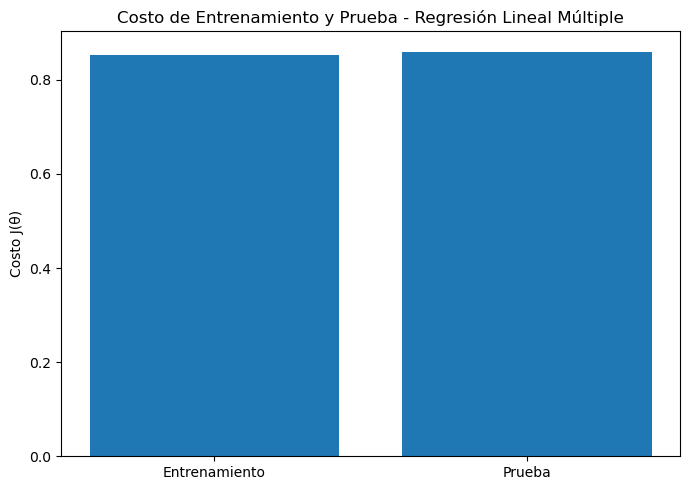

In [15]:
# Validación del modelo lineal múltiple entrenado con descenso por gradiente
J_train_lineal = computeCostMulti(X, y, theta)
J_test_lineal = computeCostMulti(x_test_pre, y_test, theta)

mse_lineal = np.mean((y_test - Y_pre) ** 2)
print(f'Costo J entrenamiento (Lineal GD): {J_train_lineal:.4f}')
print(f'Costo J prueba (Lineal GD): {J_test_lineal:.4f}')
print(f'MSE prueba (Lineal GD): {mse_lineal:.4f}')

plt.figure(figsize=(7, 5))
plt.bar(['Entrenamiento', 'Prueba'], [J_train_lineal, J_test_lineal])
plt.ylabel('Costo J(θ)')
plt.title('Costo de Entrenamiento y Prueba - Regresión Lineal Múltiple')
plt.tight_layout()
plt.show()


## 11. Regresión Polinómica Multivariable

En esta sección se aplica **regresión polinómica** tomando como base el procedimiento del cuadernillo de regresión polinómica. La diferencia es que ahora se trabaja con varias características relacionadas con el riesgo de diabetes.

Para aumentar la capacidad del modelo se agregan términos polinómicos de grado 2. Es decir, por cada característica normalizada $x_j$ se añade también $x_j^2$:

$$X_{poly} = [x_1, x_2, ..., x_n, x_1^2, x_2^2, ..., x_n^2]$$

Luego se normalizan estas nuevas características y se agrega la columna de unos para el parámetro $\theta_0$.


In [16]:
# Recargar datos originales para construir el modelo polinómico desde cero
# Se usa la misma selección de variables del modelo lineal múltiple.
data_poly = np.genfromtxt('../Database/1_diabetes_dataset.csv', delimiter=',', skip_header=1)

X_poly_original = data_poly[:, [0, 8, 9, 12, 15, 16, 17, 21, 23, 24, 25, 26, 27]]
y_poly_original = data_poly[:, 28]

# Crear características polinómicas de grado 2: X y X^2
X_poly = np.concatenate([X_poly_original, X_poly_original ** 2], axis=1)

print('Dimensión de X original:', X_poly_original.shape)
print('Dimensión de X polinómica:', X_poly.shape)

Dimensión de X original: (100000, 13)
Dimensión de X polinómica: (100000, 26)


### 11.1 Normalización de Características Polinómicas

Como los términos elevados al cuadrado pueden tener valores mucho más grandes que las variables originales, se aplica nuevamente la normalización Z-score. Esto ayuda a que el descenso por gradiente converja de forma más estable.


In [17]:
# Normalizar las características polinómicas
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

# División en entrenamiento y prueba
x_poly_train, x_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly_norm, y_poly_original, test_size=0.2, shuffle=False)

# Agregar columna de unos para theta_0
m_poly = y_poly_train.size
X_poly_train_b = np.concatenate([np.ones((m_poly, 1)), x_poly_train], axis=1)

m_poly_test = y_poly_test.size
X_poly_test_b = np.concatenate([np.ones((m_poly_test, 1)), x_poly_test], axis=1)

print('X_poly_train_b:', X_poly_train_b.shape)
print('X_poly_test_b:', X_poly_test_b.shape)


X_poly_train_b: (80000, 27)
X_poly_test_b: (20000, 27)


### 11.2 Entrenamiento con Descenso por Gradiente

Se inicializan los parámetros $\theta$ en cero y se ejecuta el descenso por gradiente usando la misma función `gradientDescentMulti`. El historial `J_history_poly` almacena el valor del costo en cada iteración para graficar la convergencia.


In [18]:
# Parámetros de entrenamiento para regresión polinómica
alpha_poly = 0.001
num_iters_poly = 4000

theta_poly = np.zeros(X_poly_train_b.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(
    X_poly_train_b, y_poly_train, theta_poly, alpha_poly, num_iters_poly
)

print('Theta calculado por descenso por gradiente - Regresión Polinómica:')
print(theta_poly)


Theta calculado por descenso por gradiente - Regresión Polinómica:
[ 2.96668032e+01  2.23266538e+00 -2.12796067e+00 -4.80058387e-01
  3.26572779e+00  7.30966188e-01  6.70188146e-02  7.78111830e-02
 -5.70206623e-01  3.07032998e-01  1.21438060e-01 -3.53335695e-02
  6.32364066e-03 -1.87900422e-02  1.95188356e+00 -6.96878376e-01
 -4.09003491e-01  3.26572779e+00  7.18981111e-01  6.45094824e-02
  3.78424253e-02 -3.90895439e-01  2.67694870e-01  1.37113965e-01
 -1.83401039e-02  7.67483576e-03 -5.94095975e-03]


### 11.3 Gráfico de Costo de la Regresión Polinómica

El siguiente gráfico muestra cómo disminuye el costo $J(\theta)$ durante el entrenamiento. Si la curva baja de forma estable, significa que el algoritmo está aprendiendo correctamente.


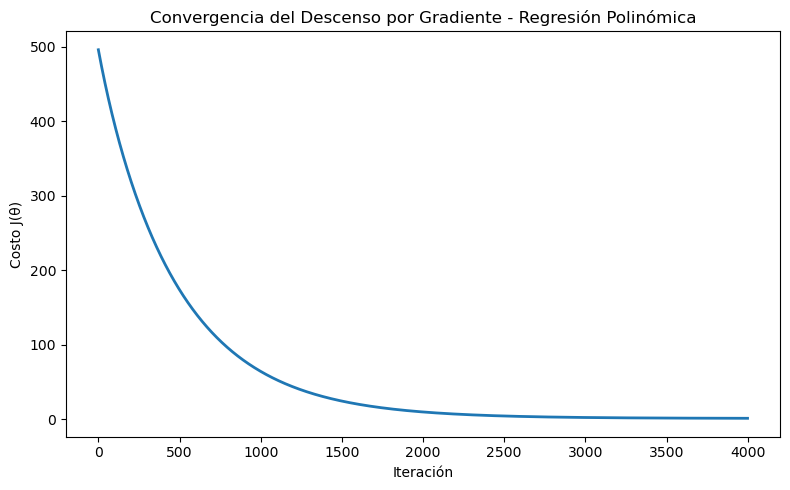

In [19]:
# Gráfica de convergencia del costo para regresión polinómica
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2)
plt.xlabel('Iteración')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Descenso por Gradiente - Regresión Polinómica')
plt.tight_layout()
plt.show()


### 11.4 Validación del Modelo Polinómico

Con el modelo entrenado se realizan predicciones sobre el conjunto de prueba. Luego se calcula el costo de entrenamiento, el costo de prueba y el error cuadrático medio para validar el desempeño del modelo.


In [20]:
# Predicciones del modelo polinómico
Y_pre_poly_train = np.dot(X_poly_train_b, theta_poly)
Y_pre_poly_test = np.dot(X_poly_test_b, theta_poly)

J_train_poly = computeCostMulti(X_poly_train_b, y_poly_train, theta_poly)
J_test_poly = computeCostMulti(X_poly_test_b, y_poly_test, theta_poly)
mse_poly = np.mean((y_poly_test - Y_pre_poly_test) ** 2)

print(f'Costo J entrenamiento (Polinómica GD): {J_train_poly:.4f}')
print(f'Costo J prueba (Polinómica GD): {J_test_poly:.4f}')
print(f'MSE prueba (Polinómica GD): {mse_poly:.4f}')

resultados_poly = pd.DataFrame({
    'Valor_Real': y_poly_test,
    'Prediccion_Polinomica': Y_pre_poly_test
})
print('\nPrimeras filas de resultados polinómicos:')
print(resultados_poly.head(10))


Costo J entrenamiento (Polinómica GD): 0.9608
Costo J prueba (Polinómica GD): 0.9659
MSE prueba (Polinómica GD): 1.9318

Primeras filas de resultados polinómicos:
   Valor_Real  Prediccion_Polinomica
0        18.8              19.682015
1        26.4              25.785240
2        25.9              25.244868
3        17.5              17.392649
4        33.7              33.445028
5        19.8              18.005481
6        31.9              32.098171
7        17.0              18.886844
8        54.6              53.493222
9        21.4              22.517464


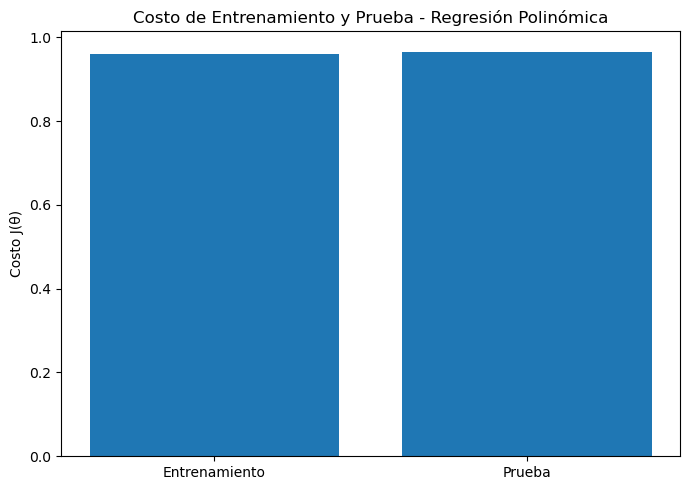

In [21]:
# Gráfico de costo de entrenamiento y prueba para regresión polinómica
plt.figure(figsize=(7, 5))
plt.bar(['Entrenamiento', 'Prueba'], [J_train_poly, J_test_poly])
plt.ylabel('Costo J(θ)')
plt.title('Costo de Entrenamiento y Prueba - Regresión Polinómica')
plt.tight_layout()
plt.show()


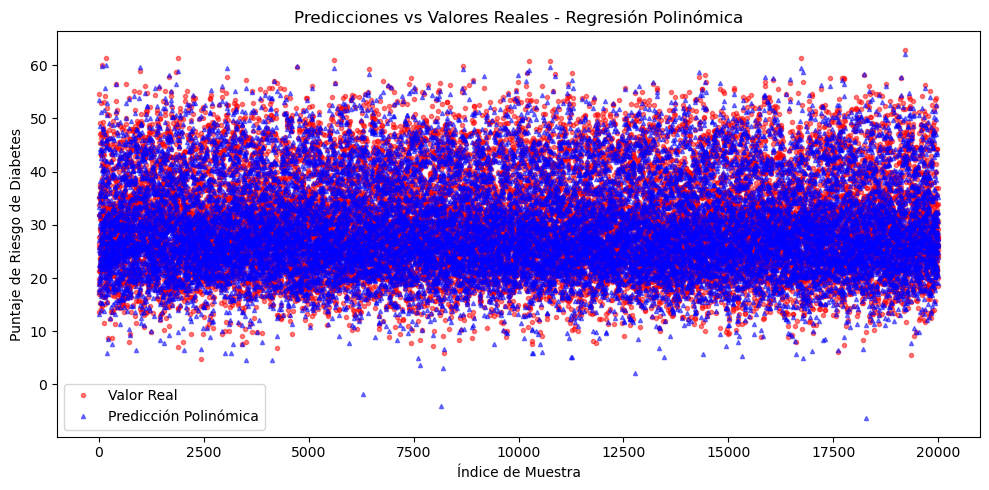

In [22]:
# Gráfico de predicciones vs valores reales para regresión polinómica
plt.figure(figsize=(10, 5))
plt.plot(resultados_poly['Valor_Real'].values, 'ro', label='Valor Real', alpha=0.5, markersize=3)
plt.plot(resultados_poly['Prediccion_Polinomica'].values, 'b^', label='Predicción Polinómica', alpha=0.5, markersize=3)
plt.xlabel('Índice de Muestra')
plt.ylabel('Puntaje de Riesgo de Diabetes')
plt.title('Predicciones vs Valores Reales - Regresión Polinómica')
plt.legend()
plt.tight_layout()
plt.show()


### 11.5 Visualización del Ajuste Polinómico con una Característica

Como el modelo tiene muchas variables, no se puede visualizar toda la superficie en un solo gráfico 2D. Para representar el ajuste, se grafica la primera característica normalizada (`age`) frente al puntaje real y frente a las predicciones del modelo polinómico.


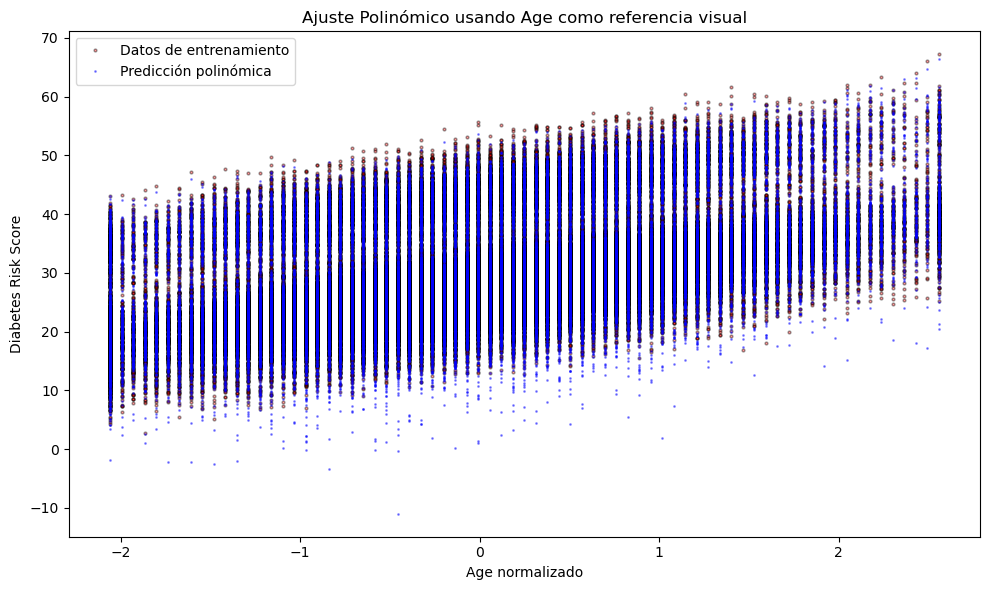

In [23]:
# Visualización usando la primera característica: age normalizada
plt.figure(figsize=(10, 6))
plt.plot(x_poly_train[:, 0], y_poly_train, 'ro', mec='k', alpha=0.4, markersize=2, label='Datos de entrenamiento')
plt.plot(x_poly_train[:, 0], Y_pre_poly_train, 'b.', alpha=0.4, markersize=2, label='Predicción polinómica')
plt.xlabel('Age normalizado')
plt.ylabel('Diabetes Risk Score')
plt.title('Ajuste Polinómico usando Age como referencia visual')
plt.legend()
plt.tight_layout()
plt.show()


<a id="section7"></a>
### 10 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [24]:
data = np.genfromtxt('../Database/1_diabetes_dataset.csv', delimiter=',', skip_header=1)

X = data[:, [0, 8, 9, 12, 15, 16, 17, 21, 23, 24, 25, 26, 27]]
y = data[:, 28]

In [25]:
# División en entrenamiento/prueba (sobre datos SIN normalizar)
x_train_n, x_test_n, y_train_n, y_test_n = train_test_split(X, y, test_size=0.2, shuffle=False)
X_ne = x_train_n   # X para ecuación normal (sin normalizar)
y_ne = y_train_n
x_test_ne = x_test_n
y_test_ne = y_test_n


In [26]:
# Agregar columna de unos para el término de sesgo (beta_0)
m_ne = y_ne.size
X_ne_b = np.concatenate([np.ones((m_ne, 1)), X_ne], axis=1)


In [27]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [28]:
# Calcula los parámetros con la ecuación de la normal
theta_normal = normalEqn(X_ne_b, y_ne)

# Muestra los resultados obtenidos a partir de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal:')
feature_labels = ['bias', 'age', 'physical_activity', 'diet_score', 'family_history',
                  'bmi', 'waist_to_hip', 'systolic_bp', 'hdl', 'triglycerides',
                  'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']
for label, t in zip(feature_labels, theta_normal):
    print(f'  {label:25s}: {t:.6f}')

# ------------------------------------------------------------------
# Predicción para un paciente de ejemplo (datos crudos, sin normalizar)
# Paciente: 55 años, 120 min/sem actividad, dieta 6.0, sin historial familiar,
#           BMI 28.0, WHR 0.85, sys_bp 125, HDL 50, trig 130,
#           gluc_fasting 110, gluc_post 170, insulina 8.0, HbA1c 6.5
# ------------------------------------------------------------------
paciente_raw = np.array([1, 55, 120, 6.0, 0, 28.0, 0.85, 125, 50, 130, 110, 170, 8.0, 6.5])
risk_score_pred = np.dot(paciente_raw, theta_normal)
print(f'\nPuntaje de riesgo de diabetes predicho para el paciente de ejemplo'
      f' (ecuación de la normal): {risk_score_pred:.2f}')


Theta calculado a partir de la ecuación de la normal:
  bias                     : 11.620135
  age                      : 0.276582
  physical_activity        : -0.035123
  diet_score               : -0.501421
  family_history           : 15.952391
  bmi                      : 0.447353
  waist_to_hip             : 0.004672
  systolic_bp              : 0.000361
  hdl                      : -0.095614
  triglycerides            : 0.012825
  glucose_fasting          : 0.004802
  glucose_postprandial     : 0.000297
  insulin_level            : 0.000464
  hba1c                    : -0.009074

Puntaje de riesgo de diabetes predicho para el paciente de ejemplo (ecuación de la normal): 29.59


### Evaluación y Visualización (Ecuación de la Normal)

Se predice sobre el conjunto de prueba y se comparan los resultados con los valores reales, de la misma forma que se hizo con el descenso por gradiente.

In [29]:
# Predicciones sobre el conjunto de prueba
m_test_ne = y_test_ne.size
x_test_pre_ne = np.concatenate([np.ones((m_test_ne, 1)), x_test_ne], axis=1)
Y_pre_ne = np.dot(x_test_pre_ne, theta_normal)

resultados_normal = pd.DataFrame({
    'Valor_Real': y_test_ne,
    'Prediccion': Y_pre_ne
})

# MSE
mse_normal = np.mean((resultados_normal['Valor_Real'] - resultados_normal['Prediccion'])**2)
print(f'MSE (Ecuación de la Normal): {mse_normal:.4f}')
print('\nPrimeras filas de resultados:')
print(resultados_normal.head(10))


MSE (Ecuación de la Normal): 1.0021

Primeras filas de resultados:
   Valor_Real  Prediccion
0        18.8   20.058025
1        26.4   26.366221
2        25.9   26.004817
3        17.5   17.902044
4        33.7   34.522130
5        19.8   18.776715
6        31.9   31.447546
7        17.0   19.143750
8        54.6   53.840393
9        21.4   21.946882


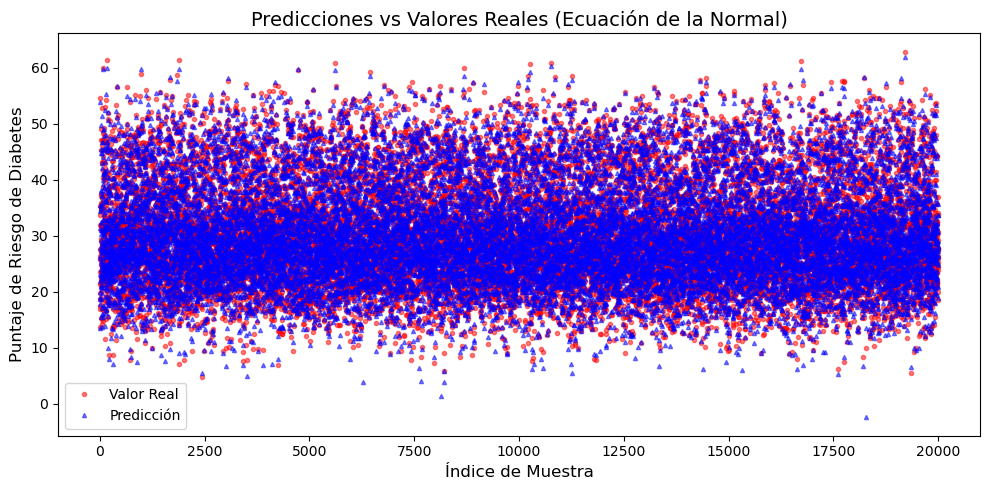

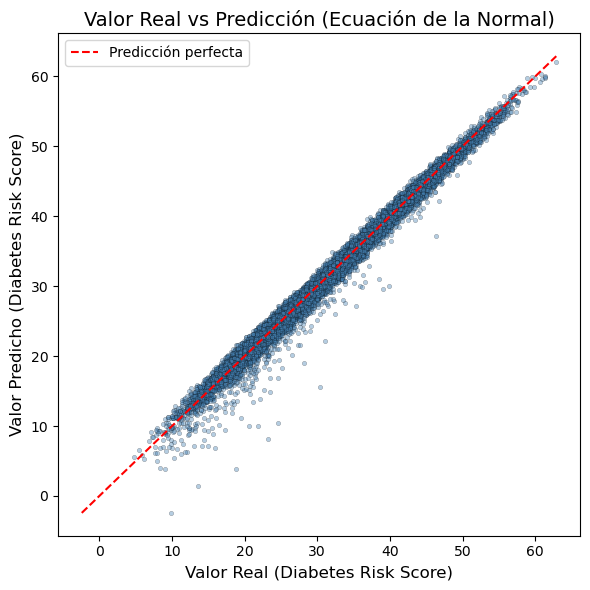

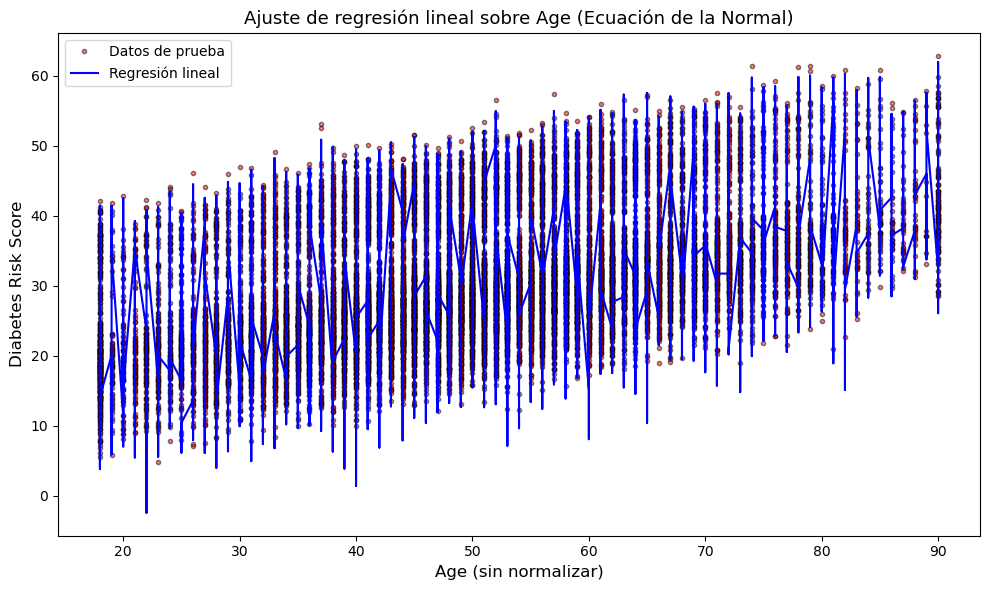

In [30]:
# --- Gráfico 1: Predicciones vs Valores Reales ---
plt.figure(figsize=(10, 5))
plt.plot(resultados_normal['Valor_Real'].values, 'ro', label='Valor Real', alpha=0.5, markersize=3)
plt.plot(resultados_normal['Prediccion'].values, 'b^', label='Predicción', alpha=0.5, markersize=3)
plt.xlabel('Índice de Muestra', fontsize=12)
plt.ylabel('Puntaje de Riesgo de Diabetes', fontsize=12)
plt.title('Predicciones vs Valores Reales (Ecuación de la Normal)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# --- Gráfico 2: Scatter Valor Real vs Predicción ---
plt.figure(figsize=(6, 6))
plt.scatter(resultados_normal['Valor_Real'], resultados_normal['Prediccion'],
            alpha=0.4, s=10, color='steelblue', edgecolors='k', linewidths=0.3)
min_val = min(resultados_normal['Valor_Real'].min(), resultados_normal['Prediccion'].min())
max_val = max(resultados_normal['Valor_Real'].max(), resultados_normal['Prediccion'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Predicción perfecta')
plt.xlabel('Valor Real (Diabetes Risk Score)', fontsize=12)
plt.ylabel('Valor Predicho (Diabetes Risk Score)', fontsize=12)
plt.title('Valor Real vs Predicción (Ecuación de la Normal)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# --- Gráfico 3: Ajuste sobre la característica Age ---
sort_idx = np.argsort(x_test_ne[:, 0])
x_test_ne_sorted = x_test_ne[sort_idx]
x_test_pre_sorted = np.concatenate([np.ones((m_test_ne, 1)), x_test_ne_sorted], axis=1)
y_pred_sorted = np.dot(x_test_pre_sorted, theta_normal)

plt.figure(figsize=(10, 6))
plt.plot(x_test_ne[:, 0], y_test_ne, 'ro', mec='k', alpha=0.5, markersize=3, label='Datos de prueba')
plt.plot(x_test_ne_sorted[:, 0], y_pred_sorted, '-', color='blue', lw=1.5, label='Regresión lineal')
plt.xlabel('Age (sin normalizar)', fontsize=12)
plt.ylabel('Diabetes Risk Score', fontsize=12)
plt.title('Ajuste de regresión lineal sobre Age (Ecuación de la Normal)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


## 13. Gráfico de Costo para la Ecuación de la Normal

La ecuación de la normal no utiliza iteraciones, por eso no genera una curva de convergencia como el descenso por gradiente. En este caso se representa el costo final de entrenamiento y prueba para validar el resultado obtenido por cálculo directo de los parámetros.


Costo J entrenamiento (Ecuación Normal): 0.5030
Costo J prueba (Ecuación Normal): 0.5010


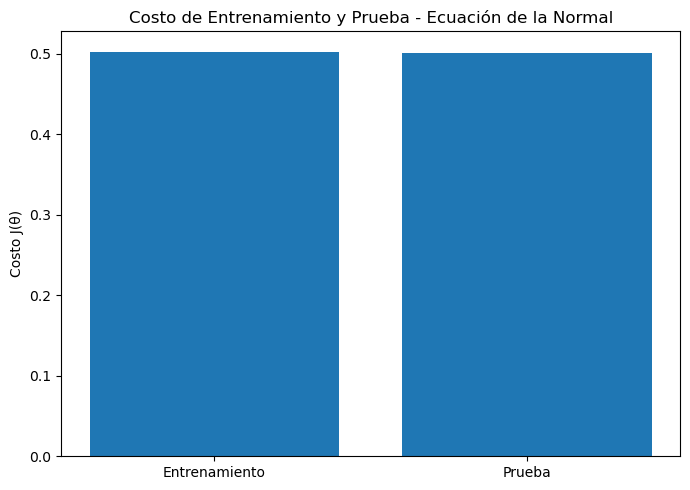

In [31]:
# Costo final para el modelo calculado con ecuación de la normal
J_train_normal = computeCostMulti(X_ne_b, y_ne, theta_normal)
J_test_normal = computeCostMulti(x_test_pre_ne, y_test_ne, theta_normal)

print(f'Costo J entrenamiento (Ecuación Normal): {J_train_normal:.4f}')
print(f'Costo J prueba (Ecuación Normal): {J_test_normal:.4f}')

plt.figure(figsize=(7, 5))
plt.bar(['Entrenamiento', 'Prueba'], [J_train_normal, J_test_normal])
plt.ylabel('Costo J(θ)')
plt.title('Costo de Entrenamiento y Prueba - Ecuación de la Normal')
plt.tight_layout()
plt.show()


## 14. Comparación Final de los Tres Modelos

Finalmente se comparan los tres modelos solicitados:

1. Regresión lineal múltiple con descenso por gradiente.
2. Regresión polinómica multivariable con descenso por gradiente.
3. Regresión lineal múltiple calculada mediante la ecuación de la normal.

La comparación usa el costo de prueba y el MSE para observar cuál modelo tiene mejor desempeño sobre datos no vistos.


            Modelo  Costo_Entrenamiento  Costo_Prueba  MSE_Prueba
0        Lineal GD             0.853053      0.859902    1.719803
1    Polinómica GD             0.960840      0.965919    1.931838
2  Ecuación Normal             0.503013      0.501036    1.002072


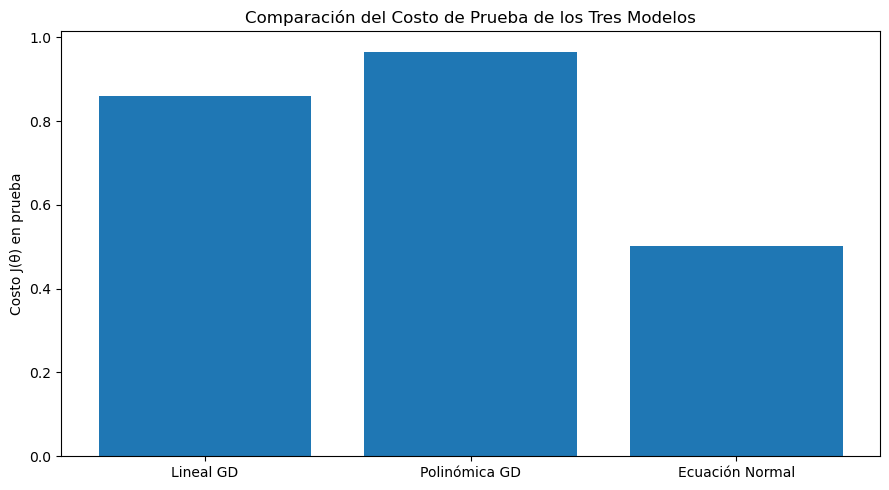

In [32]:
comparacion_modelos = pd.DataFrame({
    'Modelo': ['Lineal GD', 'Polinómica GD', 'Ecuación Normal'],
    'Costo_Entrenamiento': [J_train_lineal, J_train_poly, J_train_normal],
    'Costo_Prueba': [J_test_lineal, J_test_poly, J_test_normal],
    'MSE_Prueba': [mse_lineal, mse_poly, mse_normal]
})

print(comparacion_modelos)

plt.figure(figsize=(9, 5))
plt.bar(comparacion_modelos['Modelo'], comparacion_modelos['Costo_Prueba'])
plt.ylabel('Costo J(θ) en prueba')
plt.title('Comparación del Costo de Prueba de los Tres Modelos')
plt.tight_layout()
plt.show()
